In [1]:
# !pip3 install pandas numpy matplotlib scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm, expon

plt.rcParams["figure.figsize"] = (8, 5)

NODE_IDS = [1, 2, 3, 4]

## Load & preprocess all nodes

In [3]:
traces = {}
for node_id in NODE_IDS:
    df = pd.read_csv(f"data/node_{node_id}.csv")
    df = df.sort_values("timestamp_usec").reset_index(drop=True)
    df["timestamp_sec"] = df["timestamp_usec"] / 1e6
    traces[node_id] = df

print("Loaded nodes:", list(traces.keys()))
traces[NODE_IDS[0]].head()

Loaded nodes: [1, 2, 3, 4]


,node_id,timestamp_usec,event,term,leader_id,value,timestamp_sec
0,1,217076571735,timeout,0,-1,0,217076.571735
1,1,217077222544,became_candidate,1,-1,0,217077.222544
2,1,217078120930,timeout,1,-1,0,217078.120930
3,1,217080174184,became_follower,3,0,0,217080.174184
4,1,217081218018,heartbeat,3,0,538919,217081.218018


## Filter stable heartbeats (per node)

In [4]:
WINDOW_SEC = 5

unstable_events = {
    "timeout",
    "became_candidate",
    "became_follower",
    "became_leader"
}

def get_stable_intervals(trace):
    trace = trace.copy()
    trace["unstable"] = trace["event"].isin(unstable_events)

    unstable_times = trace.loc[trace["unstable"], "timestamp_sec"].values

    heartbeats = trace[trace["event"] == "heartbeat"].copy()
    heartbeats["near_unstable"] = heartbeats["timestamp_sec"].apply(
        lambda t: np.any(np.abs(unstable_times - t) < WINDOW_SEC)
    )

    stable = heartbeats[~heartbeats["near_unstable"]].copy()
    stable["interval"] = stable["timestamp_sec"].diff()
    intervals = stable["interval"].dropna()

    print(f"  Total heartbeats: {len(heartbeats)}, Stable: {len(stable)}, Intervals: {len(intervals)}")
    return intervals

all_intervals = {}
for node_id in NODE_IDS:
    print(f"Node {node_id}:")
    all_intervals[node_id] = get_stable_intervals(traces[node_id])

Node 1:
  Total heartbeats: 44291, Stable: 44283, Intervals: 44282
Node 2:
  Total heartbeats: 44243, Stable: 44235, Intervals: 44234
Node 3:
  Total heartbeats: 44292, Stable: 44283, Intervals: 44282
Node 4:
  Total heartbeats: 44292, Stable: 44283, Intervals: 44282


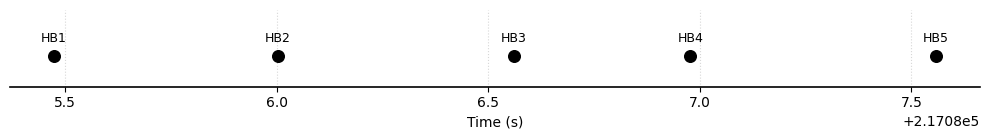

In [32]:
# Plot stable heartbeat arrivals (5 heartbeats) for a single node
node_id = NODE_IDS[0]
trace = traces[node_id].copy()

trace["unstable"] = trace["event"].isin(unstable_events)
unstable_times = trace.loc[trace["unstable"], "timestamp_sec"].values

heartbeats = trace[trace["event"] == "heartbeat"].copy()
heartbeats["near_unstable"] = heartbeats["timestamp_sec"].apply(
    lambda ts: np.any(np.abs(unstable_times - ts) < WINDOW_SEC)
)

stable_hb = heartbeats[~heartbeats["near_unstable"]].copy().head(5)

fig, ax = plt.subplots(figsize=(10, 1.5))
ax.scatter(stable_hb["timestamp_sec"], np.zeros(len(stable_hb)), s=70, color="black", zorder=3)

for i, ts_val in enumerate(stable_hb["timestamp_sec"], start=1):
    ax.text(ts_val, 0.03, f"HB{i}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Time (s)")
ax.set_yticks([])
ax.set_ylim(-0.08, 0.12)
ax.grid(axis="x", linestyle=":", alpha=0.5)

# Keep only bottom border (x-axis spine)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)

plt.tight_layout()
plt.show()

## Interval statistics (per node)

In [5]:
stats = pd.DataFrame({
    f"node_{nid}": all_intervals[nid].describe()
    for nid in NODE_IDS
})
stats

,node_1,node_2,node_3,node_4
count,44282.000000,44234.000000,44282.000000,44282.000000
mean,0.521262,0.521826,0.521250,0.521250
std,0.300807,0.290923,0.185551,0.193682
min,0.000036,0.000037,0.129806,0.102339
25%,0.450502,0.411670,0.415349,0.403037
50%,0.500721,0.549443,0.500380,0.500893
75%,0.567125,0.601939,0.623600,0.601372
max,30.259924,20.188537,11.821117,11.912259


## Heartbeat interval histogram (per node, combined)

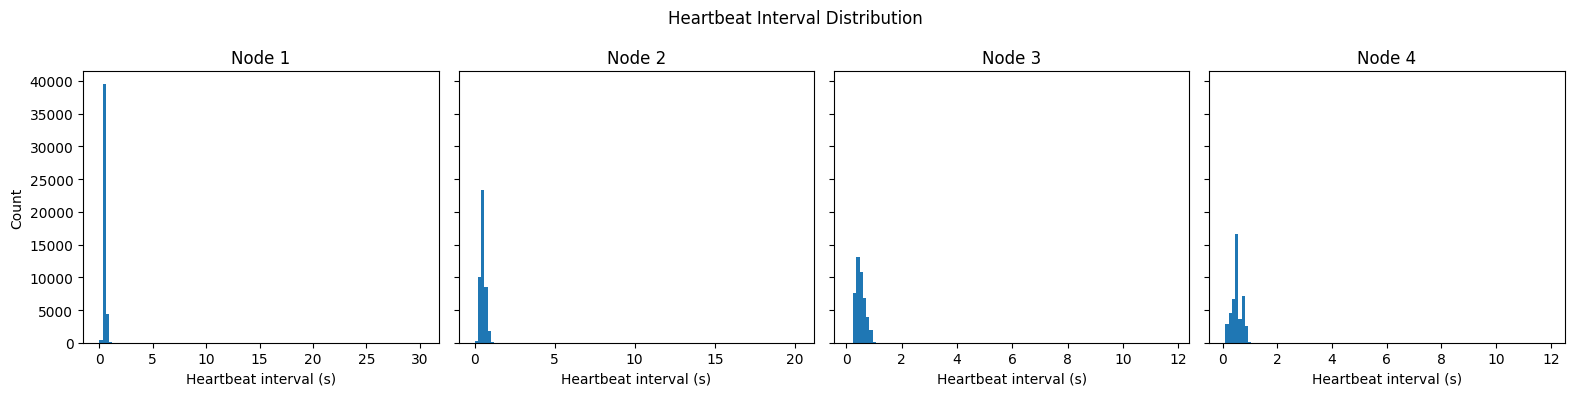

In [6]:
fig, axes = plt.subplots(1, len(NODE_IDS), figsize=(4 * len(NODE_IDS), 4), sharey=True)

for ax, node_id in zip(axes, NODE_IDS):
    ax.hist(np.sort(all_intervals[node_id].values), bins=100)
    ax.set_title(f"Node {node_id}")
    ax.set_xlabel("Heartbeat interval (s)")

axes[0].set_ylabel("Count")
plt.suptitle("Heartbeat Interval Distribution")
plt.tight_layout()
plt.show()

## Empirical CDF of heartbeat intervals (averaged across nodes, with confidence interval)

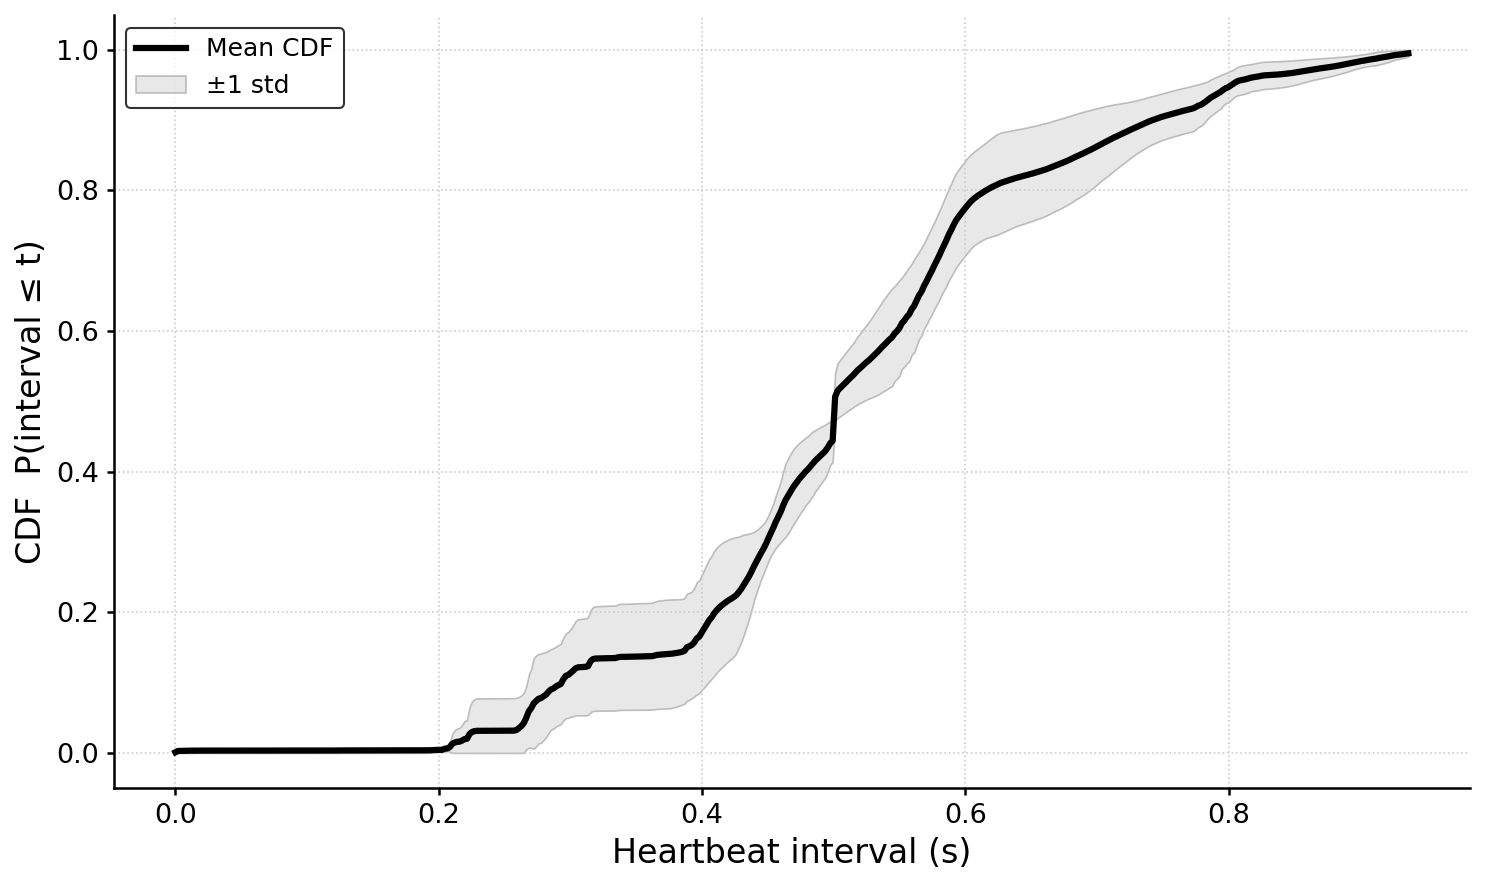

In [7]:
# Evaluate each node's empirical CDF on a shared x-grid, then average.

all_vals = np.concatenate([all_intervals[nid].values for nid in NODE_IDS])
x_grid = np.linspace(np.percentile(all_vals, 0.1), np.percentile(all_vals, 99.5), 500)

node_cdfs = {}
for node_id in NODE_IDS:
    sorted_iv = np.sort(all_intervals[node_id].values)
    cdf_vals = np.searchsorted(sorted_iv, x_grid, side="right") / len(sorted_iv)
    node_cdfs[node_id] = cdf_vals

cdf_matrix = np.vstack([node_cdfs[nid] for nid in NODE_IDS])
mean_cdf = cdf_matrix.mean(axis=0)
std_cdf = cdf_matrix.std(axis=0)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# Publication-style formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.grid(True, linestyle=":", linewidth=0.8, color="0.8")
ax.tick_params(axis="both", labelsize=13, width=1.2)

# Individual node CDFs: distinguish by line style and marker, not color
linestyles = ["-", "--", "-.", ":"]
markers = ["o", "s", "^", "D"]

# for i, node_id in enumerate(NODE_IDS):
#     ax.plot(
#         x_grid,
#         node_cdfs[node_id],
#         color="0.35",
#         linestyle=linestyles[i % len(linestyles)],
#         linewidth=2.0,
#         marker=markers[i % len(markers)],
#         markevery=40,
#         markersize=5,
#         label=f"Node {node_id}",
#     )

# Mean CDF
ax.plot(
    x_grid,
    mean_cdf,
    color="black",
    linewidth=3.0,
    linestyle="-",
    label="Mean CDF",
)

# ±1 std band
ax.fill_between(
    x_grid,
    np.clip(mean_cdf - std_cdf, 0, 1),
    np.clip(mean_cdf + std_cdf, 0, 1),
    facecolor="0.85",
    edgecolor="0.6",
    linewidth=0.8,
    alpha=0.6,
    label="±1 std",
)

ax.set_xlabel("Heartbeat interval (s)", fontsize=16)
ax.set_ylabel("CDF  P(interval ≤ t)", fontsize=16)
# ax.set_title("Heartbeat Interval CDF Across Nodes", fontsize=18, pad=12)

ax.legend(fontsize=12, frameon=True, edgecolor="black")
plt.tight_layout()
plt.show()

In [8]:
p99_stats = pd.Series(
    {f"node_{node_id}": all_intervals[node_id].quantile(0.99) for node_id in NODE_IDS},
    name="p99_interval_sec"
)

p1_sats = pd.Series(
    {f"node_{node_id}": all_intervals[node_id].quantile(0.01) for node_id in NODE_IDS},
    name="p1_interval_sec"
)

print("Heartbeat interval 99th percentile (s) per node:")
print(p99_stats)

print("Heartbeat interval 1st percentile (s) per node:")
print(p1_sats)

Heartbeat interval 99th percentile (s) per node:
node_1    0.808200
node_2    0.940220
node_3    0.934876
node_4    0.908602
Name: p99_interval_sec, dtype: float64
Heartbeat interval 1st percentile (s) per node:
node_1    0.378124
node_2    0.272943
node_3    0.259211
node_4    0.204717
Name: p1_interval_sec, dtype: float64


## φ detector functions

In [9]:
WINDOW = 100
MIN_STD = 1e-6


def phi_normal(delay, window):
    mu = np.mean(window)
    sigma = max(np.std(window), MIN_STD)
    prob = max(1 - norm.cdf((delay - mu) / sigma), 1e-12)
    return -np.log10(prob)


def phi_exponential(delay, window):
    mu = np.mean(window)
    prob = max(np.exp(-delay / mu), 1e-12)
    return -np.log10(prob)


def phi_lognormal(delay, window):
    shape, loc, scale = lognorm.fit(np.array(window), floc=0)
    prob = max(1 - lognorm.cdf(delay, shape, loc, scale), 1e-12)
    return -np.log10(prob)


def t_phi_normal(window, phi_threshold):
    mu = np.mean(window)
    sigma = max(np.std(window), MIN_STD)
    return mu + sigma * norm.ppf(1 - 10 ** (-phi_threshold))


def t_phi_exponential(window, phi_threshold):
    return -np.mean(window) * np.log(10 ** (-phi_threshold))


def t_phi_lognormal(window, phi_threshold):
    shape, loc, scale = lognorm.fit(np.array(window), floc=0)
    return lognorm.ppf(1 - 10 ** (-phi_threshold), shape, loc, scale)

## φ accrual time series (per node, combined plot)

In [10]:
def compute_phi_series(intervals, times):
    window = list(intervals[:WINDOW])
    phi_n_list, phi_e_list, phi_l_list, t_list = [], [], [], []

    for i in range(WINDOW, len(intervals)):
        delay = intervals[i]
        phi_n_list.append(phi_normal(delay, window))
        phi_e_list.append(phi_exponential(delay, window))
        phi_l_list.append(phi_lognormal(delay, window))
        t_list.append(times[i])
        window.append(delay)
        window.pop(0)

    return (
        np.array(phi_n_list),
        np.array(phi_e_list),
        np.array(phi_l_list),
        np.array(t_list),
    )


phi_series = {}
for node_id in NODE_IDS:
    iv = all_intervals[node_id].values
    ts = traces[node_id]["timestamp_sec"].values[1:]  # align with diff-derived intervals
    # ts may be longer than iv; trim to iv length
    ts = ts[:len(iv)]
    phi_series[node_id] = compute_phi_series(iv, ts)
    print(f"Node {node_id}: computed {len(phi_series[node_id][0])} φ values")

Node 1: computed 44182 φ values
Node 2: computed 44134 φ values
Node 3: computed 44182 φ values
Node 4: computed 44182 φ values


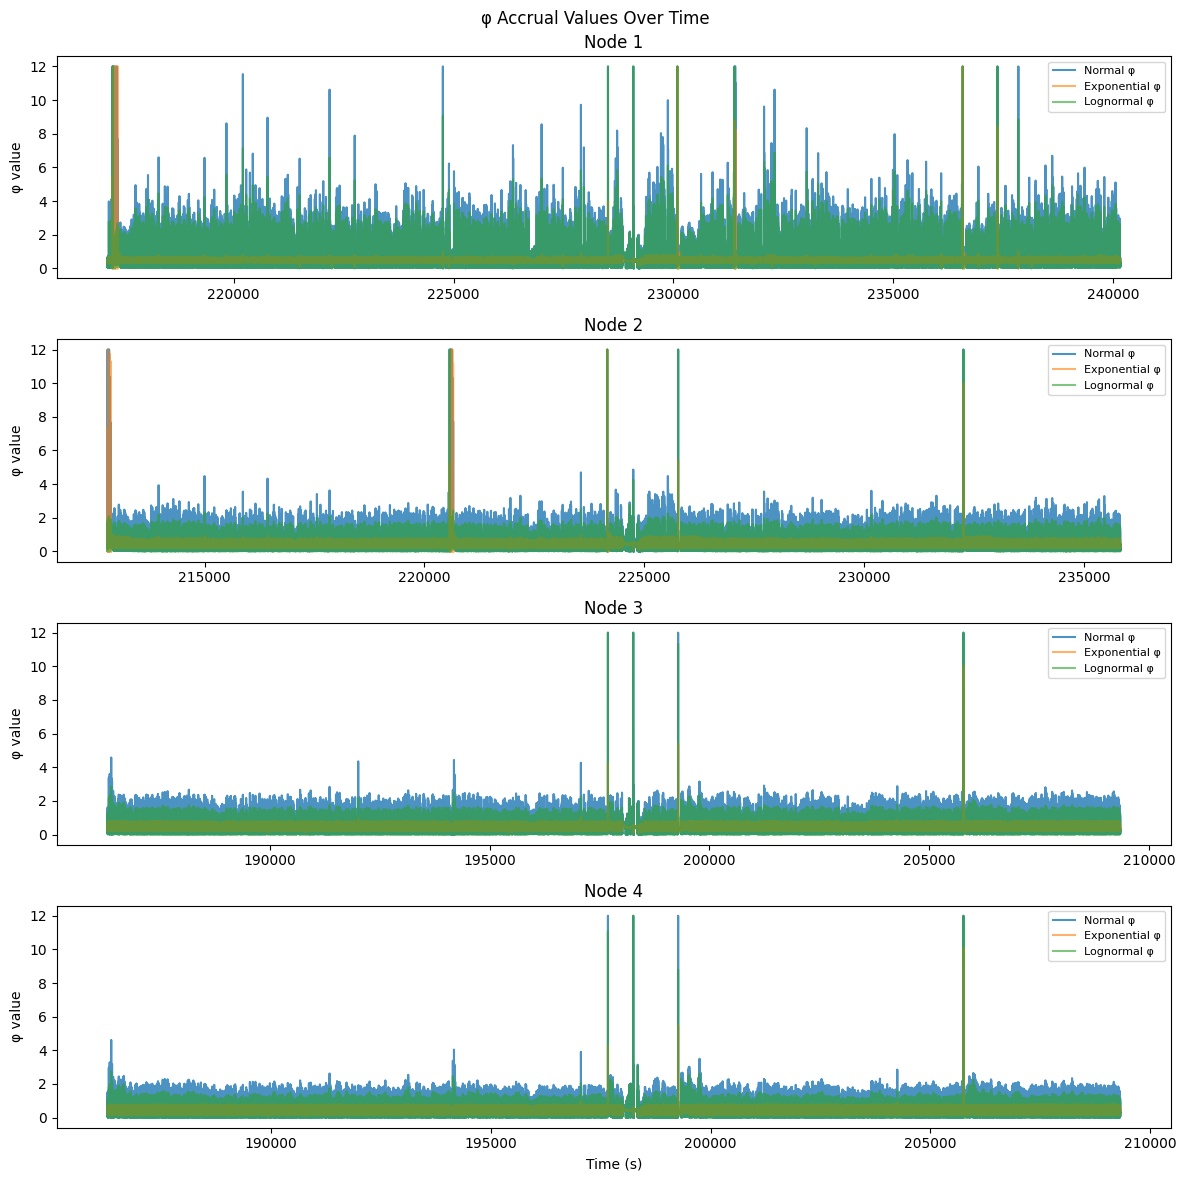

In [11]:
fig, axes = plt.subplots(len(NODE_IDS), 1, figsize=(12, 3 * len(NODE_IDS)), sharex=False)

for ax, node_id in zip(axes, NODE_IDS):
    phi_n, phi_e, phi_l, ts = phi_series[node_id]
    ax.plot(ts, phi_n, label="Normal φ", alpha=0.8)
    ax.plot(ts, phi_e, label="Exponential φ", alpha=0.6)
    ax.plot(ts, phi_l, label="Lognormal φ", alpha=0.6)
    ax.set_ylabel("φ value")
    ax.set_title(f"Node {node_id}")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time (s)")
plt.suptitle("φ Accrual Values Over Time")
plt.tight_layout()
plt.show()

## Distribution of φ values (combined histogram)

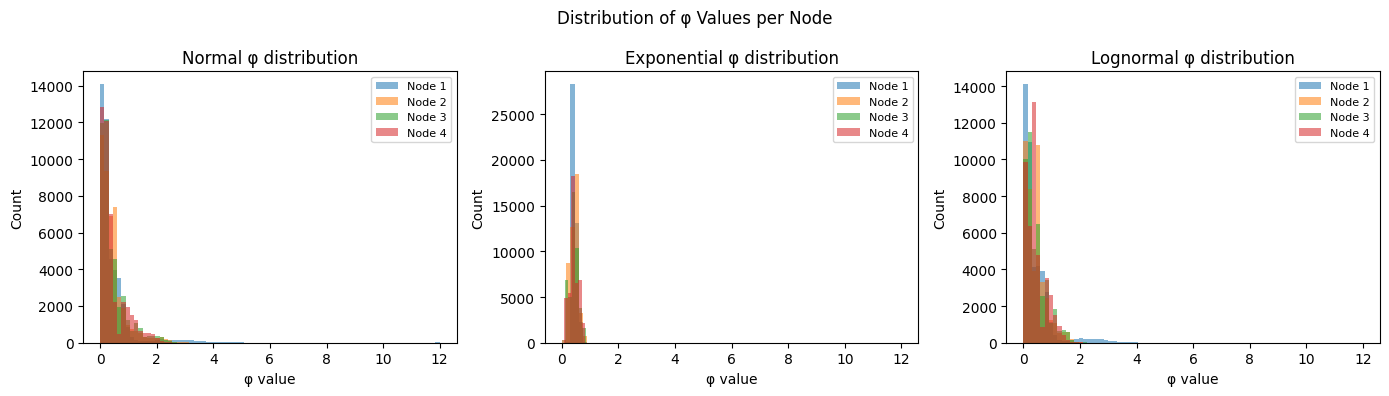

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
labels = ["Normal", "Exponential", "Lognormal"]

for ax, series_idx, label in zip(axes, [0, 1, 2], labels):
    for node_id in NODE_IDS:
        series = phi_series[node_id][series_idx]
        ax.hist(series, bins=80, alpha=0.55, label=f"Node {node_id}")
    ax.set_xlabel("φ value")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} φ distribution")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of φ Values per Node")
plt.tight_layout()
plt.show()

## Fitted distributions vs empirical CDF (per node + combined)

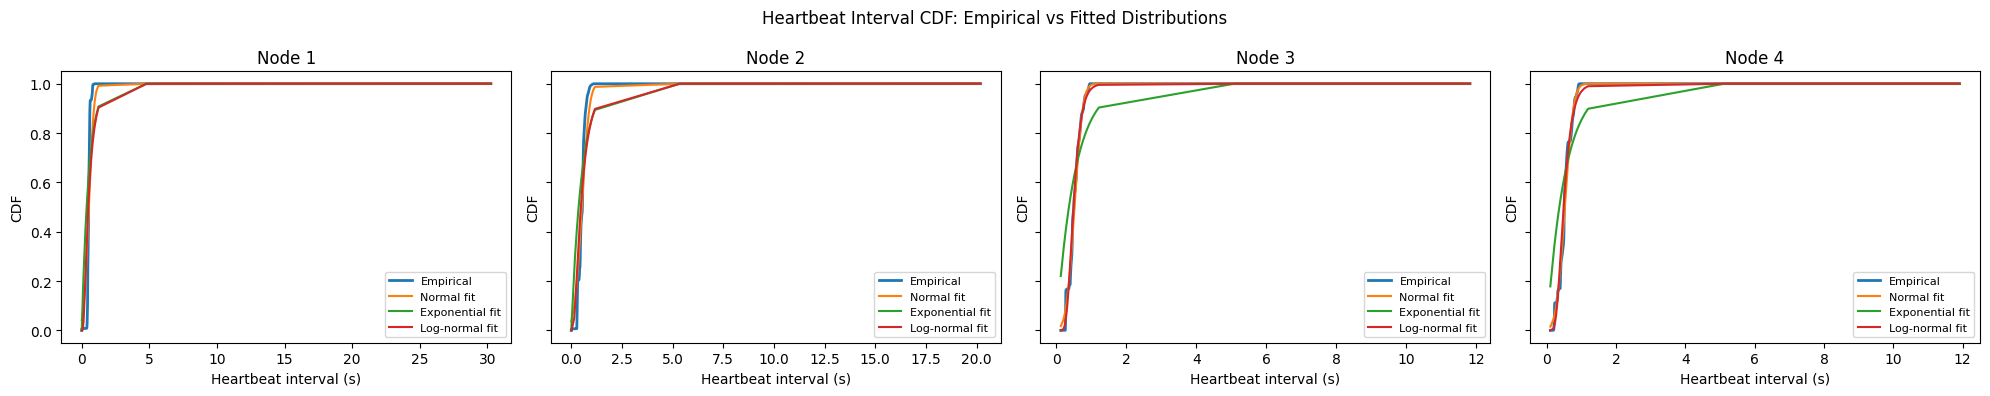

In [13]:
def fit_and_plot_cdf(ax, intervals, title):
    data = np.sort(intervals)
    emp_cdf = np.arange(1, len(data) + 1) / len(data)

    mu_n, sigma_n = norm.fit(data)
    loc_e, scale_e = expon.fit(data, floc=0)
    shape_l, loc_l, scale_l = lognorm.fit(data, floc=0)

    ax.plot(data, emp_cdf, label="Empirical", linewidth=2)
    ax.plot(data, norm.cdf(data, mu_n, sigma_n), label="Normal fit")
    ax.plot(data, expon.cdf(data, loc_e, scale_e), label="Exponential fit")
    ax.plot(data, lognorm.cdf(data, shape_l, loc_l, scale_l), label="Log-normal fit")

    ax.set_xlabel("Heartbeat interval (s)")
    ax.set_ylabel("CDF")
    ax.set_title(title)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, len(NODE_IDS), figsize=(5 * len(NODE_IDS), 4), sharey=True)

for ax, node_id in zip(axes, NODE_IDS):
    fit_and_plot_cdf(ax, all_intervals[node_id].values, f"Node {node_id}")

plt.suptitle("Heartbeat Interval CDF: Empirical vs Fitted Distributions")
plt.tight_layout()
plt.show()

## False election rate vs φ threshold (per node, combined)

In [40]:
PHI_THRESHOLDS = [4.0, 5.0, 6.0, 8.0]


def compute_election_rates(intervals, times):
    runtime_hours = (times[-1] - times[0]) / 3600
    results = []

    for thr in PHI_THRESHOLDS:
        elections_n = elections_e = elections_l = 0
        window = list(intervals[:WINDOW])

        for i in range(WINDOW, len(intervals)):
            delta = intervals[i]
            if delta > t_phi_normal(window, thr):      elections_n += 1
            if delta > t_phi_exponential(window, thr): elections_e += 1
            if delta > t_phi_lognormal(window, thr):   elections_l += 1
            window.append(delta)
            window.pop(0)

        results.append((
            thr,
            elections_n / runtime_hours, 
            elections_e / runtime_hours,
            elections_l / runtime_hours,
        ))

    return pd.DataFrame(results,
        columns=["phi", "normal_eph", "exp_eph", "lognormal_eph"])


election_results = {}
for node_id in NODE_IDS:
    iv = all_intervals[node_id].values
    ts = traces[node_id]["timestamp_sec"].values[1:][:len(iv)]
    election_results[node_id] = compute_election_rates(iv, ts)
    print(f"Node {node_id} done")

Node 1 done
Node 2 done
Node 3 done
Node 4 done


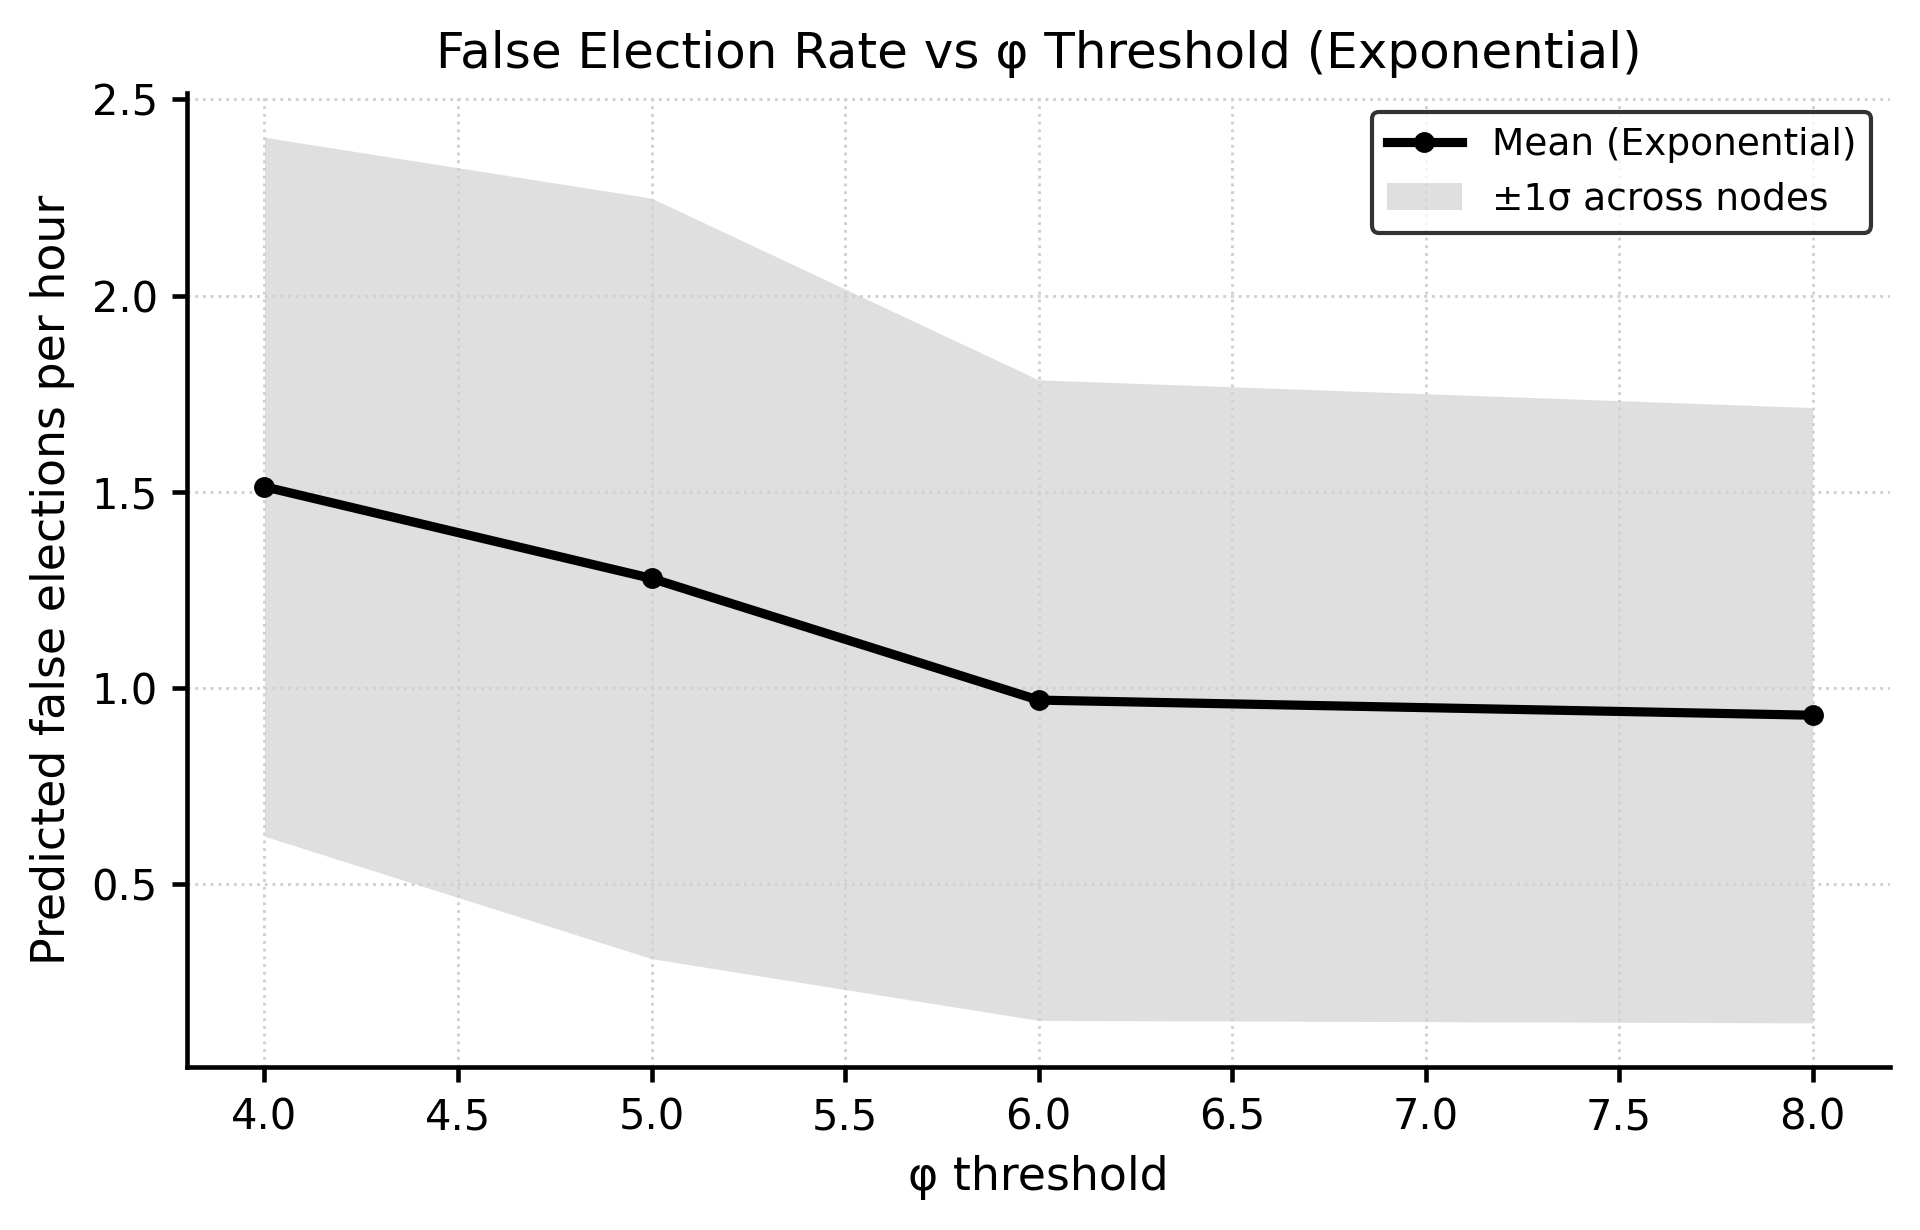

In [45]:
phi_vals = np.array(list(PHI_THRESHOLDS))
col = "exp_eph"

# Stack per-node curves for Exponential model: shape (n_nodes, n_thresholds)
exp_rates = np.vstack([election_results[nid][col].values for nid in NODE_IDS])

mean_rate = exp_rates.mean(axis=0)
std_rate = exp_rates.std(axis=0)

# Keep lower band positive for log-scale plotting
eps = 1e-6
lower = np.maximum(mean_rate - std_rate, eps)
upper = mean_rate + std_rate

fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=300)

# Paper-style formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)
ax.grid(True, linestyle=":", linewidth=0.7, color="0.82")
ax.tick_params(axis="both", labelsize=10, width=1.1)

# Mean ± 1σ
ax.plot(
    phi_vals, mean_rate,
    color="black", linewidth=2.2, marker="o", markersize=4,
    label="Mean (Exponential)"
)
ax.fill_between(
    phi_vals, lower, upper,
    color="0.5", alpha=0.25, linewidth=0,
    label="±1σ across nodes"
)

ax.set_xlabel("φ threshold", fontsize=11)
ax.set_ylabel("Predicted false elections per hour", fontsize=11)
ax.set_title("False Election Rate vs φ Threshold (Exponential)", fontsize=12)
ax.legend(frameon=True, edgecolor="black", fontsize=9)

plt.tight_layout()
plt.show()

## False election rate vs randomized timeout T (per node, combined)

In [46]:
T_VALUES = [1.0, 1.5, 2.0, 2.5]
TRIALS = 50


def compute_timeout_rates(intervals, times):
    runtime_hours = (times[-1] - times[0]) / 3600
    results = []

    for T in T_VALUES:
        total = 0
        for _ in range(TRIALS):
            elections = sum(1 for delta in intervals if delta > np.random.uniform(T, 2 * T))
            total += elections
        results.append((T, (total / TRIALS) / runtime_hours))

    return pd.DataFrame(results, columns=["base_timeout_T", "elections_per_hour"])


timeout_results = {}
for node_id in NODE_IDS:
    iv = all_intervals[node_id].values
    ts = traces[node_id]["timestamp_sec"].values[1:][:len(iv)]
    timeout_results[node_id] = compute_timeout_rates(iv, ts)
    print(f"Node {node_id} done")

Node 1 done
Node 2 done
Node 3 done
Node 4 done


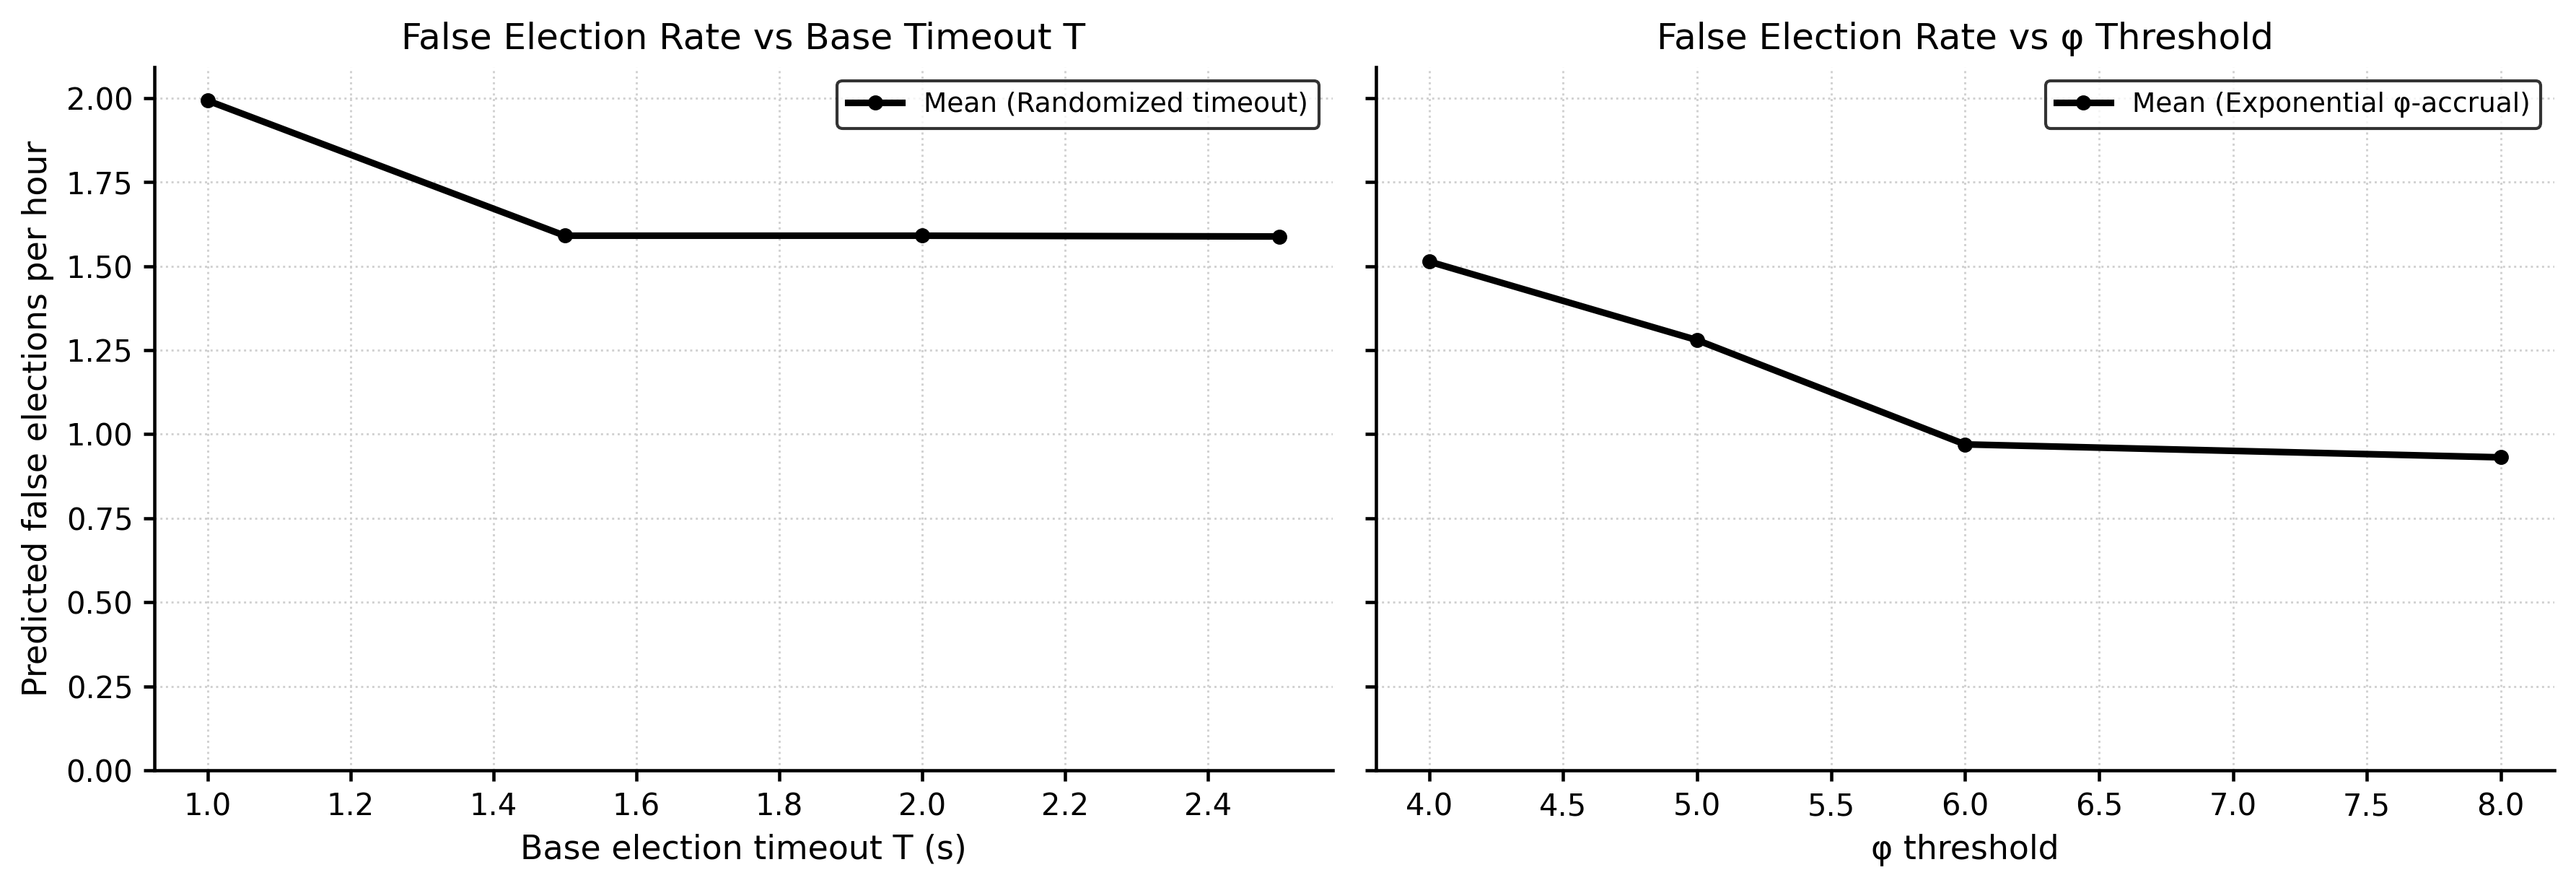

In [49]:
# Timeout-based false election rate (mean only, no std shading)
t_vals = np.array(T_VALUES)
timeout_rates = np.vstack([timeout_results[nid]["elections_per_hour"].values for nid in NODE_IDS])
timeout_mean_rate = timeout_rates.mean(axis=0)

# Exponential φ-accrual false election rate (mean only, no std shading)
phi_vals = np.array(PHI_THRESHOLDS)
exp_rates = np.vstack([election_results[nid]["exp_eph"].values for nid in NODE_IDS])
exp_mean_rate = exp_rates.mean(axis=0)

y_max = max(timeout_mean_rate.max(), exp_mean_rate.max()) * 1.05

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=300, sharey=True)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)
    ax.grid(True, linestyle=":", linewidth=0.7, color="0.82")
    ax.tick_params(axis="both", labelsize=10, width=1.1)
    ax.set_ylim(0, y_max)

# Left: randomized timeout model
axes[0].plot(
    t_vals, timeout_mean_rate,
    color="black", linewidth=2.2, marker="o", markersize=4,
    label="Mean (Randomized timeout)"
)
axes[0].set_xlabel("Base election timeout T (s)", fontsize=11)
axes[0].set_ylabel("Predicted false elections per hour", fontsize=11)
axes[0].set_title("False Election Rate vs Base Timeout T", fontsize=12)
axes[0].legend(frameon=True, edgecolor="black", fontsize=9)

# Right: exponential φ-accrual model
axes[1].plot(
    phi_vals, exp_mean_rate,
    color="black", linewidth=2.2, marker="o", markersize=4,
    label="Mean (Exponential φ-accrual)"
)
axes[1].set_xlabel("φ threshold", fontsize=11)
axes[1].set_title("False Election Rate vs φ Threshold", fontsize=12)
axes[1].legend(frameon=True, edgecolor="black", fontsize=9)

plt.tight_layout()
plt.show()

## φ accrual growth using fitted distributions (per node, averaged)

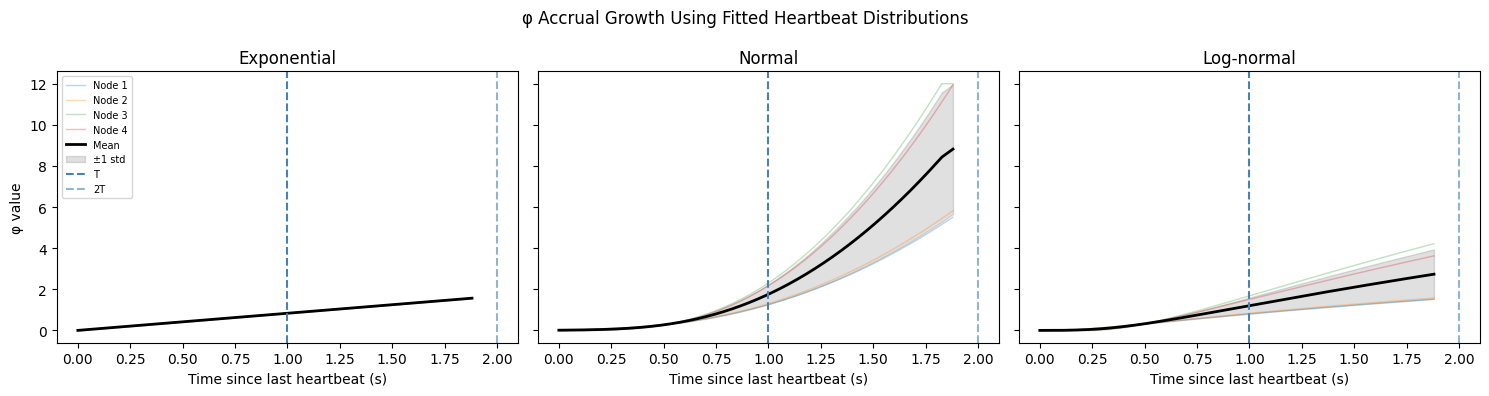

In [44]:
T = 1.0

dist_names = ["Exponential", "Normal", "Log-normal"]

# For each node, fit the three distributions and compute phi curves on a shared t-axis.
# Then average across nodes and show per-node spread as CI.

all_phi_curves = {name: [] for name in dist_names}
t_max_global = 0

node_params = {}
for node_id in NODE_IDS:
    data = all_intervals[node_id].values
    mu_n, sigma_n = norm.fit(data)
    loc_e, scale_e = expon.fit(data, floc=0)
    shape_l, loc_l, scale_l = lognorm.fit(data, floc=0)
    node_params[node_id] = (mu_n, sigma_n, loc_e, scale_e, shape_l, loc_l, scale_l)
    t_max_global = max(t_max_global, max(3 * mu_n, np.percentile(data, 99) * 2))

t = np.linspace(0, t_max_global, 500)

for node_id in NODE_IDS:
    mu_n, sigma_n, loc_e, scale_e, shape_l, loc_l, scale_l = node_params[node_id]

    phi_exp  = -np.log10(np.maximum(1 - expon.cdf(t, loc_e, scale_e), 1e-12))
    phi_norm = -np.log10(np.maximum(1 - norm.cdf(t, mu_n, sigma_n), 1e-12))
    phi_logn = -np.log10(np.maximum(1 - lognorm.cdf(t, shape_l, loc_l, scale_l), 1e-12))

    all_phi_curves["Exponential"].append(phi_exp)
    all_phi_curves["Normal"].append(phi_norm)
    all_phi_curves["Log-normal"].append(phi_logn)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, name in zip(axes, dist_names):
    curves = np.array(all_phi_curves[name])   # shape (4, 500)
    mean_phi = curves.mean(axis=0)
    std_phi  = curves.std(axis=0)

    # Individual node curves (faint)
    for i, node_id in enumerate(NODE_IDS):
        ax.plot(t, curves[i], alpha=0.3, linewidth=1, label=f"Node {node_id}")

    # Mean
    ax.plot(t, mean_phi, color="black", linewidth=2, label="Mean")

    # ±1 std CI
    ax.fill_between(t,
                    np.clip(mean_phi - std_phi, 0, None),
                    mean_phi + std_phi,
                    color="black", alpha=0.12, label="±1 std")

    ax.axvline(T,   linestyle="--", color="steelblue", label="T")
    ax.axvline(2*T, linestyle="--", color="steelblue", alpha=0.6, label="2T")

    ax.set_title(name)
    ax.set_xlabel("Time since last heartbeat (s)")

axes[0].set_ylabel("φ value")
axes[0].legend(fontsize=7)

plt.suptitle("φ Accrual Growth Using Fitted Heartbeat Distributions")
plt.tight_layout()
plt.show()